# PS 1 — Rozkład średniej z próby i Centralne Twierdzenie Graniczne

**Statystyka matematyczna — Data Science**

**Imię i nazwisko:** Marcin Zubowski  
**Grupa:** PS2  **Data:** 05.10.2026

## Cel zajęć

Na tych zajęciach nie będziemy zaczynać od gotowych wzorów.  
Najpierw będziemy **obserwować**, potem **przewidywać**, a dopiero na końcu porównamy wyniki z teorią.

Chcemy zrozumieć:
- czym różni się rozkład pojedynczej zmiennej od rozkładu średniej z próby,
- dlaczego jedna średnia to jeszcze nie „rozkład średniej”,
- co dzieje się z rozkładem średnich, gdy rośnie liczebność próby,
- jak pojawia się rozkład normalny,
- jaki jest sens Centralnego Twierdzenia Granicznego.

## Zasada pracy

W miejscach oznaczonych **Najpierw pomyśl** wpisz przewidywanie **przed uruchomieniem kolejnego kodu**.

W miejscach oznaczonych **Wniosek** wpisz krótką interpretację wyniku.

Możesz korzystać z dokumentacji i AI, ale powinieneś/powinnaś rozumieć cały kod i wszystkie wnioski w raporcie.

## 0. Przygotowanie

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Jedna zmienna i jedna średnia

Niech

$
X\sim U(0,1).
$

Z wykładu wiemy, że dla zmiennej jednostajnej:

$
E(X)=\frac12.
$

Najpierw wylosujmy **jedną próbę 30 obserwacji**.

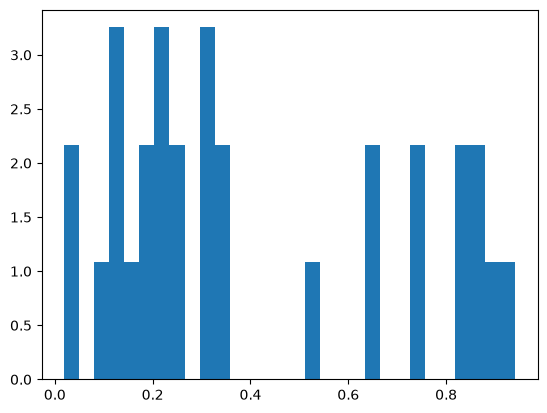

In [31]:
X = np.random.uniform(0, 1, 30)
X
plt.hist(X, bins=30, density=True)
plt.show()

### Najpierw pomyśl

1. Ile średnich można obliczyć z tej jednej próby?
2. Jakiej wartości tej średniej mniej więcej oczekujesz?

**Twoja odpowiedź:**

1. Z jednej próby można obliczyć jedną średnią
2. Wartość średniej będzie zbliżona do 0.5

In [32]:
X.mean()

np.float64(0.41286182106744734)

### Wniosek

Czy otrzymana średnia jest dokładnie równa \(0.5\)?  
Czy to jest problem?

Średnia nie jest dokładnie równa 0.5, ale nie jest to problem. Im więcej obserwacji będzie w danej próbie tym bliżej oczekiwanego wyniku będziemy.

# 2. Jedna średnia to jeszcze nie rozkład średniej

Jeżeli chcemy badać **rozkład średniej z próby**, musimy powtarzać eksperyment wiele razy.

Każdy wiersz poniższej macierzy będzie osobną próbą 30-elementową.

### Najpierw pomyśl

Jeśli utworzymy 10 000 prób po 30 obserwacji, ile średnich otrzymamy?

Otrzymamy 10 000 średnich.

In [33]:
X = np.random.uniform(0, 1, (10000, 30))
X.shape

(10000, 30)

Spróbuj teraz obliczyć średnią **osobno dla każdego wiersza**.

Podpowiedź: interesuje nas kierunek `axis=1`.

In [34]:
srednie = X.mean(axis=1)
srednie[:10]

array([0.46725135, 0.50623191, 0.49108342, 0.46190195, 0.51471481,
       0.55795496, 0.48840576, 0.44421437, 0.54292507, 0.57681185])

### Najpierw pomyśl

Jakiego kształtu histogramu średnich się spodziewasz?

Kształt podobny do rozkładu normalnego (dzwon Gaussa).

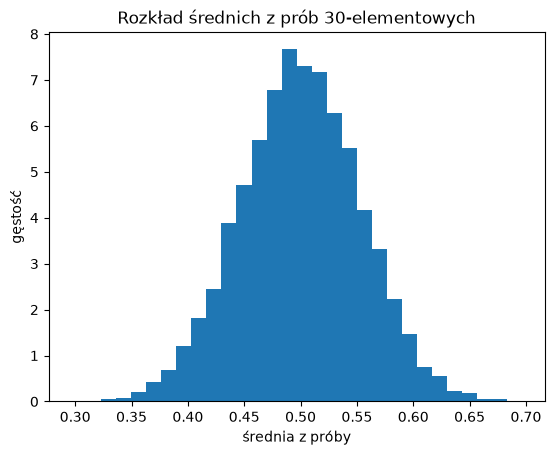

In [35]:
plt.hist(srednie, bins=30, density=True)
plt.title("Rozkład średnich z prób 30-elementowych")
plt.xlabel("średnia z próby")
plt.ylabel("gęstość")
plt.show()

### Wniosek

1. Wokół jakiej wartości skupiają się średnie?
2. Czy histogram średnich przypomina histogram pojedynczych obserwacji z $U(0,1)$?
3. Czy rozkład średnich jest bardziej skupiony czy bardziej rozproszony?

Odpowiedzi:
1. Wartości skupiają się w wartości 0.5
2. Nie
3. Rozkład średnich jest bardziej skupiony

# 3. Co zmienia liczebność próby?

Teraz porównamy średnie dla:

$
n=5,\quad n=30,\quad n=100.
$

### Najpierw pomyśl

Zanim uruchomisz kod, przewidź:

- czy środek rozkładu średnich się zmieni?
- co stanie się z rozrzutem?
- czy histogram będzie bardziej czy mniej „dzwonowy”?

**Przewidywanie:**

- środek rozkładu średnich nie zmieni się
- będzie mniejszy rozrzut
- histogram będzie bardziej "dzwonowy" (będzie jeszcze bardziej skoncentrowany w wartości oczekiwanej)

n = 5
średnia średnich = 0.5008363314655884
odchylenie standardowe średnich = 0.12808851186116976


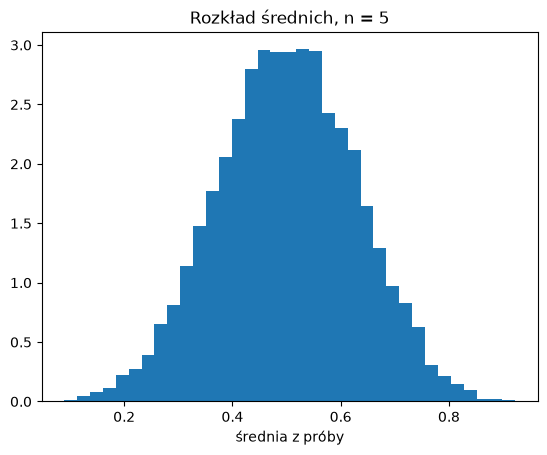

n = 30
średnia średnich = 0.5004006389718745
odchylenie standardowe średnich = 0.05303011306230403


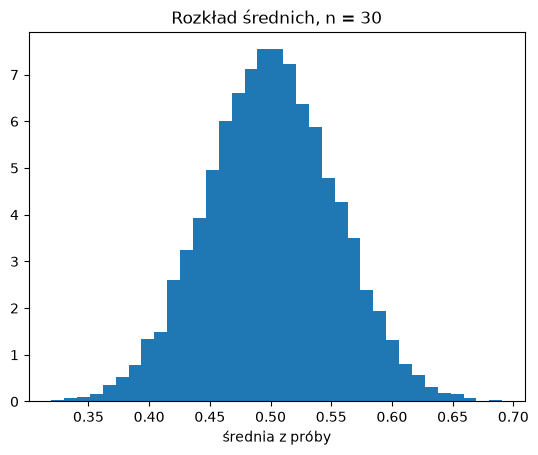

n = 100
średnia średnich = 0.5004326082609409
odchylenie standardowe średnich = 0.02846465972776674


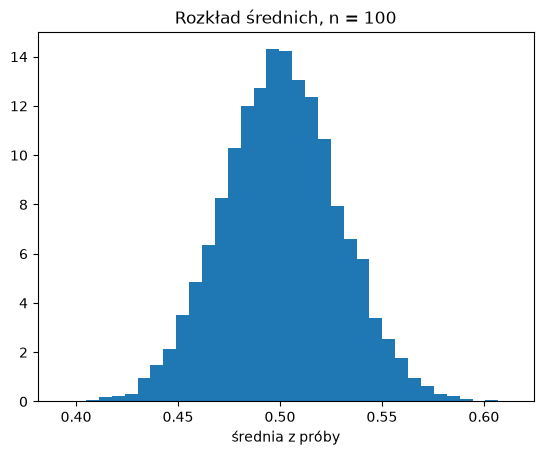

In [36]:
for n in [5, 30, 100]:
    X = np.random.uniform(0, 1, (10000, n))
    srednie = X.mean(axis=1)

    print(f"n = {n}")
    print("średnia średnich =", srednie.mean())
    print("odchylenie standardowe średnich =", srednie.std())

    plt.hist(srednie, bins=35, density=True)
    plt.title(f"Rozkład średnich, n = {n}")
    plt.xlabel("średnia z próby")
    plt.show()

### Wniosek

Uzupełnij:

- środek rozkładu średnich jest w przybliżeniu równy 0.5 (nie zmienił się)
- wraz ze wzrostem $n$ rozrzut średnich zmniejsza się
- kształt rozkładu średnich staje się bardziej dzwonowy (skoncentrowany w 0.5)


# 4. Porównanie z teorią

Dla $X_i\sim U(0,1)$:

$
\mu=\frac12,\qquad
\sigma^2=\frac1{12}.
$

Dla średniej z próby:

$
\bar X=\frac1n\sum_{i=1}^n X_i.
$

Z teorii:

$
E(\bar X)=\mu,
\qquad
\operatorname{Var}(\bar X)=\frac{\sigma^2}{n},
\qquad
SD(\bar X)=\frac{\sigma}{\sqrt n}.
$

### Zadanie

Dla $n=30$ oblicz teoretyczne odchylenie standardowe średniej.

In [37]:
n = 30

mu = 0.5
sigma = np.sqrt(1/12)

sd_teoria = sigma / np.sqrt(n)

print(sd_teoria)

0.05270462766947299


### Wniosek

Porównaj wartość teoretyczną z odchyleniem standardowym średnich uzyskanym wcześniej z symulacji.

Odchylenie standardowe średnich z symulacji dla n = 30 wynosiło: 0.052655080625645174.
Teoretyczna wartość za to wynosi: 0.05270462766947299
Zatem różnica między nimi jest bardzo nie wielka.

# 5. Standaryzacja średniej

Dla $n=30$ rozważamy

$
Z=
\frac{\bar X-\mu}{\sigma/\sqrt n}.
$

### Najpierw pomyśl

Jeśli standaryzacja została wykonana poprawnie, jakiej wartości średniej i odchylenia standardowego zmiennej $Z$ się spodziewasz?

Wartość średniej będzie bardzo niska (bliska 0), a odchylenie standardowej prawie równe 1.

In [38]:
n = 30
X = np.random.uniform(0, 1, (10000, n))
srednie = X.mean(axis=1)

Z = (srednie - 0.5) / (np.sqrt(1/12) / np.sqrt(n))

print("średnia Z =", Z.mean())
print("odchylenie standardowe Z =", Z.std())

średnia Z = 0.013558624337260409
odchylenie standardowe Z = 0.9983663077431582


### Wniosek

Czy wyniki są zgodne z przewidywaniem?

Tak

# 6. Porównanie z rozkładem normalnym

Teraz porównamy histogram standaryzowanych średnich z gęstością $N(0,1)$.

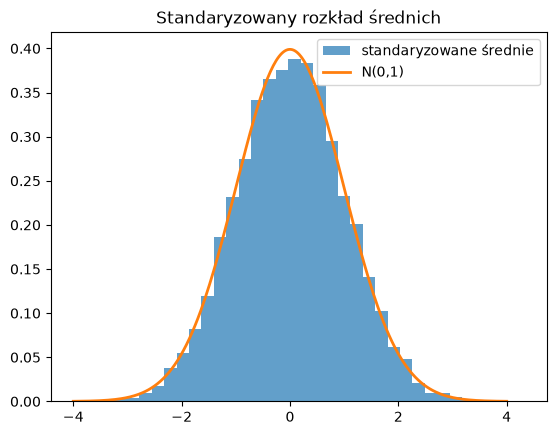

In [39]:
x = np.linspace(-4, 4, 300)
normal_density = (1/np.sqrt(2*np.pi)) * np.exp(-x**2/2)

plt.hist(Z, bins=35, density=True, alpha=0.7, label="standaryzowane średnie")
plt.plot(x, normal_density, linewidth=2, label="N(0,1)")
plt.legend()
plt.title("Standaryzowany rozkład średnich")
plt.show()

### Wniosek

Jak dobrze histogram pokrywa się z krzywą normalną?

Histogram bardzo dobrze pokrywa się z krzywą normalną.

Czy pojedyncze obserwacje miały rozkład normalny?

Nie

Co więc stało się z **rozkładem średnich**?

Średnia wielu niezależnych prób po odpowiedniej standaryzacji będzie dążyła do rozkładu normalnego. Mówi o tym CTG (centralne twierdzenie graniczne).

# 7. Trudniejszy przypadek — rozkład asymetryczny

Teraz wybierzemy rozkład, który wyraźnie nie jest normalny:

$
X_i\sim Exp(1).
$

Dla niego:

$
E(X_i)=1,\qquad Var(X_i)=1.
$

Najpierw zobaczmy rozkład pojedynczych obserwacji.

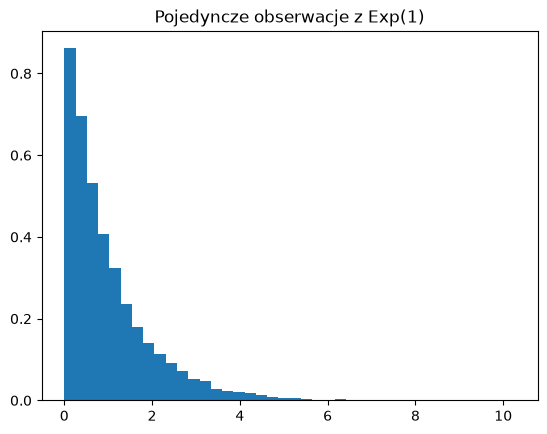

In [40]:
X = np.random.exponential(scale=1, size=10000)

plt.hist(X, bins=40, density=True)
plt.title("Pojedyncze obserwacje z Exp(1)")
plt.show()

### Najpierw pomyśl

Czy rozkład średniej z próby $n=30$ będzie wyglądał podobnie?

Nie, będzie przybliżony do rozkładu normalnego.

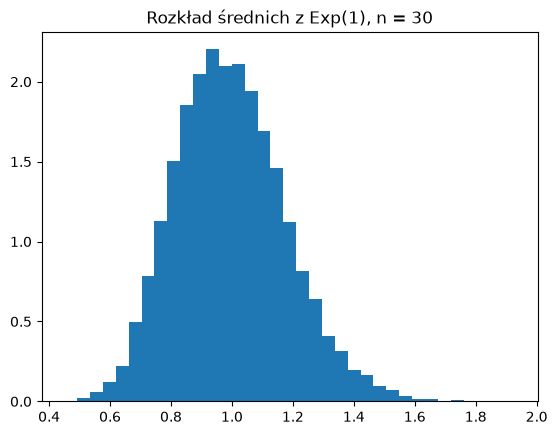

In [41]:
n = 30
X = np.random.exponential(scale=1, size=(10000, n))
srednie_exp = X.mean(axis=1)

plt.hist(srednie_exp, bins=35, density=True)
plt.title("Rozkład średnich z Exp(1), n = 30")
plt.show()

### Wniosek

Porównaj kształt rozkładu pojedynczych obserwacji z rozkładem średnich.

Rozkład średnich w porównaniu do pojedyńczej obserwacji przypomina bardziej przesunięty rozkład normalny.

# 8. Standaryzacja średniej dla rozkładu wykładniczego

Dla $Exp(1)$:

$
\mu=1,\qquad \sigma=1.
$

Zatem

$
Z=
\frac{\bar X-1}{1/\sqrt n}.
$

Uzupełnij kod.

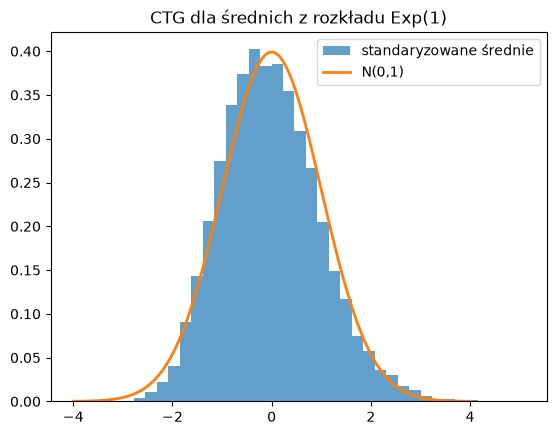

In [42]:
n = 30

Z_exp = (srednie_exp - 1) / (1/np.sqrt(n))

plt.hist(Z_exp, bins=35, density=True, alpha=0.7, label="standaryzowane średnie")
plt.plot(x, normal_density, linewidth=2, label="N(0,1)")
plt.legend()
plt.title("CTG dla średnich z rozkładu Exp(1)")
plt.show()

### Najważniejszy wniosek

Uzupełnij własnymi słowami:

> Mimo że pojedyncza zmienna \(X\) ma rozkład wykładniczy,
> rozkład średniej z odpowiednio dużej próby staje się normalny.


# 9. Zadanie samodzielne

Czas oczekiwania na obsługę klienta ma rozkład wykładniczy o średniej 20 minut.

Przyjmij:

$
X_i\sim Exp(\text{średnia }20).
$

### Polecenie

Zbadaj symulacyjnie rozkład średniego czasu obsługi dla:

$
n=5,\qquad n=30,\qquad n=100.
$

Dla każdego $n$:

1. wygeneruj 10 000 prób,
2. policz średnią z każdej próby,
3. podaj średnią rozkładu średnich,
4. podaj odchylenie standardowe rozkładu średnich,
5. porównaj z wartościami teoretycznymi,
6. narysuj histogram,
7. napisz, dla którego $n$ rozkład średniej najbardziej przypomina rozkład normalny.

### Twój kod

n = 5
Średnia z każdej próby: [ 6.46397974 24.3026495   8.8263632  12.76615046 21.54179318 18.74843654
 36.09659599 24.54743978 43.32367148 23.05509705]
Średnia rozkładu średnich: 19.94639942732044
Odchylenie rozkładu średnich: 8.952262066100507
Teoretyczna średnia: 20
Teoretyczne odchylenie: 8.94427190999916
Różnica średniej: 0.05360057267956009
Różnica odchylenia: 0.007990156101348234


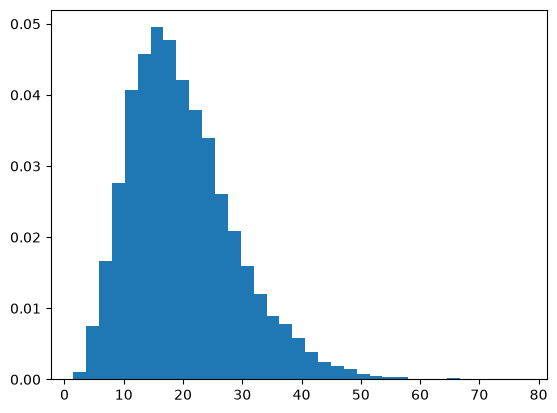

n = 30
Średnia z każdej próby: [20.36482855 22.19956939 17.29107905 23.11522366 15.82262986 15.37266634
 19.2339385  18.3205998  20.74608258 16.62848116]
Średnia rozkładu średnich: 19.935443883855978
Odchylenie rozkładu średnich: 3.627739995343519
Teoretyczna średnia: 20
Teoretyczne odchylenie: 3.6514837167011076
Różnica średniej: 0.06455611614402201
Różnica odchylenia: 0.0237437213575884


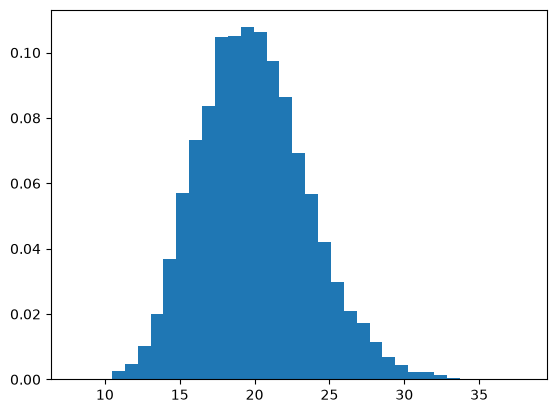

n = 100
Średnia z każdej próby: [19.19655984 21.08779827 20.55451467 20.99130527 20.68733476 16.75732544
 19.36954693 20.45378411 20.03283161 20.204886  ]
Średnia rozkładu średnich: 20.01073968881632
Odchylenie rozkładu średnich: 2.006134529706296
Teoretyczna średnia: 20
Teoretyczne odchylenie: 2.0
Różnica średniej: 0.010739688816318704
Różnica odchylenia: 0.006134529706296021


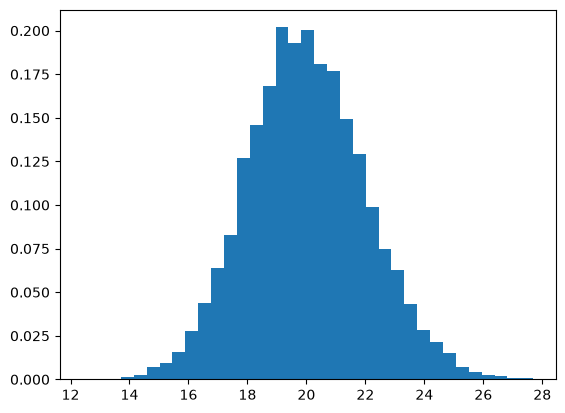

Rozkład średniej dla n = 100 najbardziej przypomina rozkład normalny


In [43]:
for n in [5, 30, 100]:
    X = np.random.exponential(scale=20, size=(10000, n))
    srednie_exp = X.mean(axis=1)

    print(f"n = {n}")
    print(f"Średnia z każdej próby: {srednie_exp[:10]}")
    print(f"Średnia rozkładu średnich: {srednie_exp.mean()}")
    print(f"Odchylenie rozkładu średnich: {srednie_exp.std()}")
    print("Teoretyczna średnia: 20")
    print(f"Teoretyczne odchylenie: {20/np.sqrt(n)}")
    print(f"Różnica średniej: {abs(20-srednie_exp.mean())}\nRóżnica odchylenia: {abs(srednie_exp.std() - (20/np.sqrt(n)))}")

    plt.hist(srednie_exp, bins=35, density=True)
    plt.show()

print("Rozkład średniej dla n = 100 najbardziej przypomina rozkład normalny")

### Wniosek do zadania samodzielnego

Średni czas oczekiwania, dla coraz większej ilości obserwacji będzie zbliżał się do rozkładu normalnego. Różnica pomiędzy teoretycznymi wartościami średniej i odchylenia standardowego, a faktycznymi wynikiami również będzie się zmieniać (mniejszy błąd). 

# 10. Pytania kontrolne

Odpowiedz krótko.

**1. Czy jedna obliczona średnia jest rozkładem średniej? Dlaczego?**

Nie, rozkład średniej będzie przypominał rozkład normalny, ponieważ mamy wiele niezależnych prób.

**2. Jak zmienia się $SD(\bar X)$, gdy rośnie $n$?**

$SD(\bar X)$ będzie malało

**3. Czy $E(\bar X)$ zależy od $n$?**

Nie

**4. Czy rozkład zmiennej $X$ musi być normalny, aby rozkład średniej był w przybliżeniu normalny dla dużego $n$?**

Nie, jak w przykładzie z rozkładem wykładniczym, ostatecznie w przybliżeniu otrzymujemy rozkład normalny dla dużego n

**5. Co w praktyce oznacza Centralne Twierdzenie Graniczne dla średniej z próby?**

Niezależnie od rozkładu zmiennej przy dostatecznie dużej liczbie prób będzie dążyć do wartości oczekiwanej.

# 11. Wnioski końcowe

Napisz 4–6 zdań. Skup się na tym:
- czym jest rozkład średniej,
- co dzieje się z jego środkiem,
- co dzieje się z jego rozrzutem,
- jaki wpływ ma $n$,
- gdzie pojawia się rozkład normalny.

Rozkład średniej to prawdopodobieństwo wartości dla wielu niezależnych prób i będzie dążył do rozkładu normalnego. Środek będzie znajdował się w wartości oczekiwanej. Im większe n tym bardziej rozkład będzie dzwonowy a rozrzut będzie się zmniejszał. Rozkład normalny pojawia się w wielu codziennych statystykach np. IQ, wzrost czy waga.

# 12. Deklaracja wykorzystania AI

Korzystanie z AI (np. NotebookLM, ChatGPT, Gemini) jest dozwolone do:
- wyjaśniania pojęć,
- wyszukiwania składni Pythona,
- diagnozowania błędów,
- dyskusji nad interpretacją wyników.

Student odpowiada za poprawność rozwiązania i powinien rozumieć cały oddany kod.

**Czy korzystałem/am z AI?** NIE

**Narzędzie/narzędzia:**  
................................................................................

**Do czego wykorzystałem/am AI?**  
................................................................................

**Podaj jeden przykład pytania/promptu skierowanego do AI:**  
................................................................................

**Czy odpowiedź AI wymagała sprawdzenia, poprawienia lub modyfikacji? Jeśli tak — czego?**  
................................................................................

> Oświadczam, że rozumiem przedstawiony w raporcie kod, potrafię wyjaśnić zastosowane metody oraz samodzielnie interpretuję otrzymane wyniki.

**Imię i nazwisko:** Marcin Zubowski

# Oddanie raportu

Przed oddaniem:

1. uruchom notebook od początku do końca (`Run All`),
2. sprawdź, czy wszystkie komórki wykonują się bez błędów,
3. pozostaw widoczne wyniki i wykresy,
4. uzupełnij wszystkie pola **Najpierw pomyśl**, **Wniosek** i pytania kontrolne,
5. uzupełnij deklarację AI,
6. zapisz jako `Nazwisko_Imie_PS01.ipynb`,
7. wyeksportuj również `Nazwisko_Imie_PS01.html`,
8. prześlij oba pliki na Moodle.